### **VEHICLE COUNT PREDICTION FROM SENSOR DATA**

Sensor at road junctions collect vehicle count data at different times which helps transport managers make informed descisions.In this article we will predict vehicle count based on this sensor data using machine learning techniques.

Problem type: Supervised Machine learning-----> Regression

Implementation of vehicle count prediction.

Dataset which we will be using contain two attributes:
Datetime-Timestamp of when data was collected

Vehicles-Number of vehicles at the timestamp

Since vehicles is a numeric attribute,using Regression would be the best choice.Regression is a supervised learning technique used to predict a numeric value based on historical data.So we will use Random Forest regressor that predicts the target by averaging the results of multiple descision tree

In [112]:
# 1. IMPORT LIBRARIES AND LOAD DATA SET
# We will be using pandas library for
# data manipulation and loading dataset into DataFrame.
import pandas as pd
df=pd.read_csv('/content/vehicles.csv')
df

,DateTime,Vehicles
0,2015-11-01 00:00:00,15
1,2015-11-01 01:00:00,13
2,2015-11-01 02:00:00,10
3,2015-11-01 03:00:00,7
4,2015-11-01 04:00:00,9
...,...,...
48115,2017-06-30 19:00:00,11
48116,2017-06-30 20:00:00,30
48117,2017-06-30 21:00:00,16
48118,2017-06-30 22:00:00,22


In [113]:
# IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [114]:
df.head()
# first 5 rows

,DateTime,Vehicles
0,2015-11-01 00:00:00,15
1,2015-11-01 01:00:00,13
2,2015-11-01 02:00:00,10
3,2015-11-01 03:00:00,7
4,2015-11-01 04:00:00,9


In [115]:
df.shape
# Dataset contain 48120 rows and 2 columns


(48120, 2)

In [116]:
# UNDERSTAND THE DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Vehicles  48120 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 752.0+ KB


In [117]:
df.describe()
# statistical information

,Vehicles
count,48120.000000
mean,22.791334
std,20.750063
min,1.000000
25%,9.000000
50%,15.000000
75%,29.000000
max,180.000000


In [118]:
# check column names
df.columns

Index(['DateTime', 'Vehicles'], dtype='object')

In [119]:
# CHECKING MISSING VALUES
df.isnull().sum()
# there is no missing values

,0
DateTime,0
Vehicles,0


In [120]:
# CHECK DUPLICATES
df.duplicated().sum()

np.int64(1082)

In [121]:
df=df.drop_duplicates()
# removing duplicates

In [122]:
df.shape

(47038, 2)

In [123]:
# CONVERT DATE - currently date time is an object/string.
df['DateTime'] = pd.to_datetime(df['DateTime'])

/tmp/ipykernel_621/3173291784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DateTime'] = pd.to_datetime(df['DateTime'])


In [124]:
df.dtypes

,0
DateTime,datetime64[ns]
Vehicles,int64


In [126]:
# SORT THE DATA BY TIME
df=df.sort_values('DateTime')
df=df.reset_index(drop=True)
df

,DateTime,Vehicles
0,2015-11-01 00:00:00,15
1,2015-11-01 00:00:00,6
2,2015-11-01 00:00:00,9
3,2015-11-01 01:00:00,6
4,2015-11-01 01:00:00,13
...,...,...
47033,2017-06-30 22:00:00,29
47034,2017-06-30 23:00:00,27
47035,2017-06-30 23:00:00,78
47036,2017-06-30 23:00:00,39


In [13]:
# 2. FEATURE ENGINEERING
# extract useful features from Datetime attribute such as day,weekday,hour,month,year
# get_dom(dt):extract day of the month(2020-01-15    return 15)
# get_weekday(dt):extract weekday (monday-0,tuesday-1 and so on)
# get_hour(dt):extract hour(15:30:00  15 hr)
# get_year(dt):extract year(2020-01-15  2020)
# get_month(dt):extract month(2020-01-15  01)
# get_dayofyear(dt):extract day of the year(2020-01-15  15)
# get_weekofyear(dt):extract week of the year(2020-01-15  1)
# df['DateTime'] = df['DateTime'].map(pd.to_datetime)---create newcolumn into proper datetime
# df['date'] = df['DateTime'].map(get_dom)---newcolumn date
# df['weekday'] =df['DateTime'].map(get_weekday)----newcolumn weekday
# df['hour'] = df['DateTime'].map(get_hour)==new column hour
# df['month'] = df['DateTime'].map(get_month)--new column month
# df['year'] = df['DateTime'].map(get_year)---new column year
# df['dayofyear'] = df['DateTime'].map(get_dayofyear)---new column day of year
# df['weekofyear'] = df['DateTime'].map(get_weekofyear)---new column week of year

In [127]:
# FEATURE ENGINEERING

df['date'] = df['DateTime'].dt.day
df['weekday'] = df['DateTime'].dt.weekday
df['hour'] = df['DateTime'].dt.hour
df['month'] = df['DateTime'].dt.month
df['year'] = df['DateTime'].dt.year
df['dayofyear'] = df['DateTime'].dt.dayofyear

df['weekofyear'] = (
    df['DateTime']
    .dt.isocalendar()
    .week
    .astype(int)
)
df.head()

,DateTime,Vehicles,date,weekday,hour,month,year,dayofyear,weekofyear
0,2015-11-01 00:00:00,15,1,6,0,11,2015,305,44
1,2015-11-01 00:00:00,6,1,6,0,11,2015,305,44
2,2015-11-01 00:00:00,9,1,6,0,11,2015,305,44
3,2015-11-01 01:00:00,6,1,6,1,11,2015,305,44
4,2015-11-01 01:00:00,13,1,6,1,11,2015,305,44


In [128]:
# CREATED TRAFFIC LAG FEATURES
df['Lag_1'] = df['Vehicles'].shift(1)
df['Lag_2'] = df['Vehicles'].shift(2)
df['Lag_3'] = df['Vehicles'].shift(3)
df['Lag_24'] = df['Vehicles'].shift(24)

In [129]:
# ROLLING AVERAGE-calculate average traffic over previous hours
df['Rolling_Mean_3'] = df['Vehicles'].shift(1).rolling(3).mean()
df['Rolling_Mean_24'] = df['Vehicles'].shift(1).rolling(24).mean()

In [130]:
# remove rows with missing values  created by lagging
df.isnull().sum()

,0
DateTime,0
Vehicles,0
date,0
weekday,0
hour,0
month,0
year,0
dayofyear,0
weekofyear,0
Lag_1,1


In [132]:
df = df.dropna().reset_index(drop=True)
df

,DateTime,Vehicles,date,weekday,hour,month,year,dayofyear,weekofyear,Lag_1,Lag_2,Lag_3,Lag_24,Rolling_Mean_3,Rolling_Mean_24
0,2015-11-01 09:00:00,12,1,6,9,11,2015,305,44,3.0,3.0,11.0,15.0,5.666667,6.500000
1,2015-11-01 09:00:00,6,1,6,9,11,2015,305,44,12.0,3.0,3.0,6.0,6.000000,6.375000
2,2015-11-01 10:00:00,8,1,6,10,11,2015,305,44,6.0,12.0,3.0,9.0,7.000000,6.375000
3,2015-11-01 10:00:00,15,1,6,10,11,2015,305,44,8.0,6.0,12.0,6.0,8.666667,6.333333
4,2015-11-01 10:00:00,12,1,6,10,11,2015,305,44,15.0,8.0,6.0,13.0,9.666667,6.708333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47009,2017-06-30 22:00:00,29,30,4,22,6,2017,181,26,84.0,26.0,22.0,16.0,44.000000,43.583333
47010,2017-06-30 23:00:00,27,30,4,23,6,2017,181,26,29.0,84.0,26.0,90.0,46.333333,44.125000
47011,2017-06-30 23:00:00,78,30,4,23,6,2017,181,26,27.0,29.0,84.0,16.0,46.666667,41.500000
47012,2017-06-30 23:00:00,39,30,4,23,6,2017,181,26,78.0,27.0,29.0,32.0,44.666667,44.083333


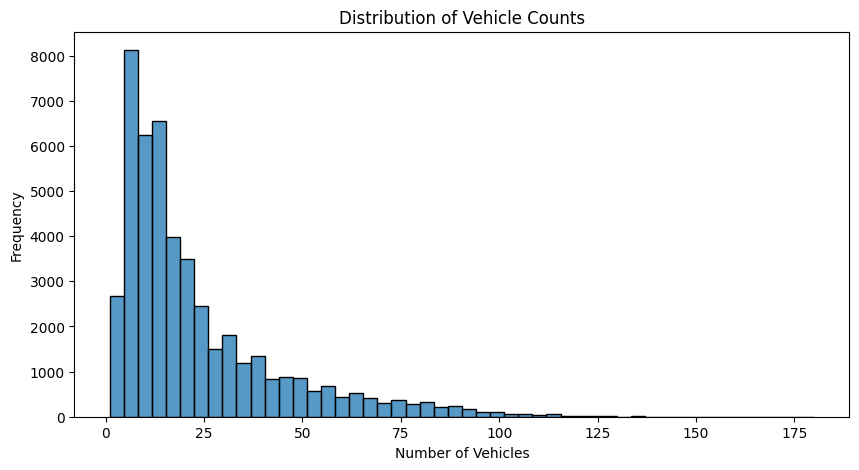

In [133]:
# EXPLORATORY DATA ANALYSIS
# a)VEHICLE COUNT DISTRIBUTION
plt.figure(figsize=(10,5))
sns.histplot(df['Vehicles'], bins=50)
plt.title('Distribution of Vehicle Counts')
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')
plt.show()

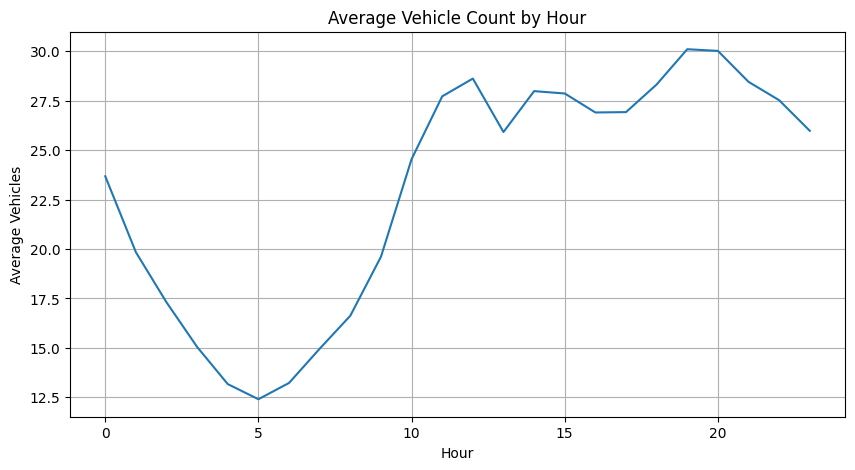

In [134]:
# b)Traffic by hour
hourly = df.groupby('hour')['Vehicles'].mean()

plt.figure(figsize=(10,5))
hourly.plot()
plt.title('Average Vehicle Count by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Vehicles')
plt.grid()
plt.show()

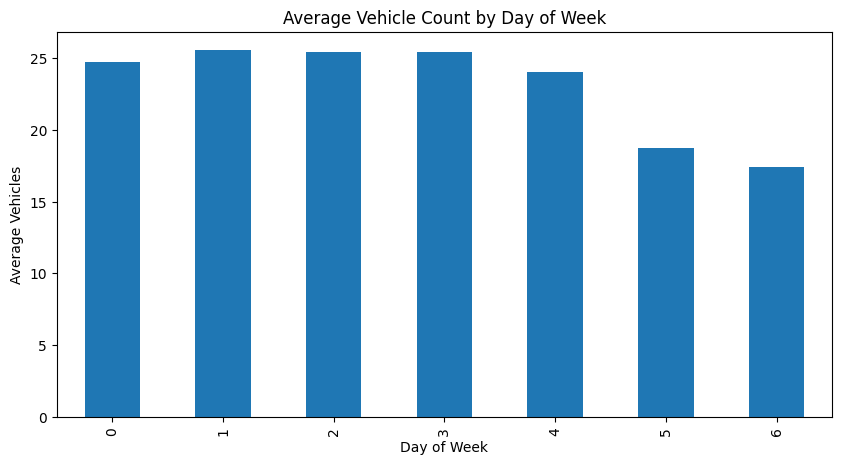

In [135]:
weekly = df.groupby('weekday')['Vehicles'].mean()

plt.figure(figsize=(10,5))
weekly.plot(kind='bar')
plt.title('Average Vehicle Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Vehicles')
plt.show()

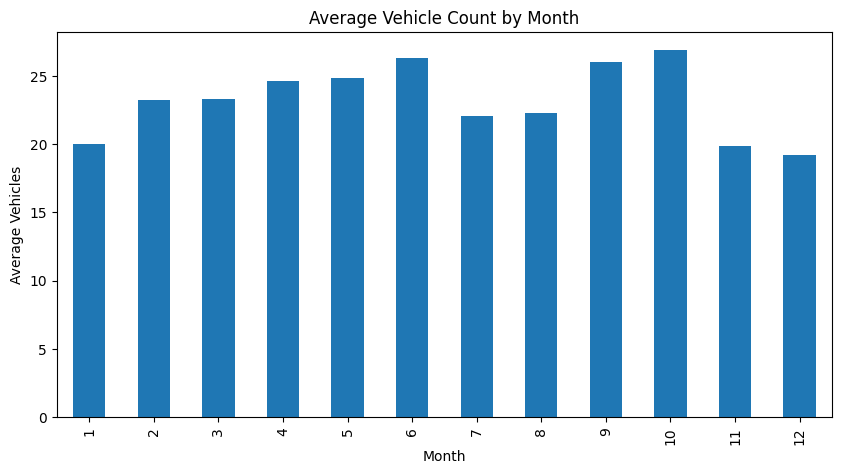

In [136]:
monthly = df.groupby('month')['Vehicles'].mean()

plt.figure(figsize=(10,5))
monthly.plot(kind='bar')
plt.title('Average Vehicle Count by Month')
plt.xlabel('Month')
plt.ylabel('Average Vehicles')
plt.show()

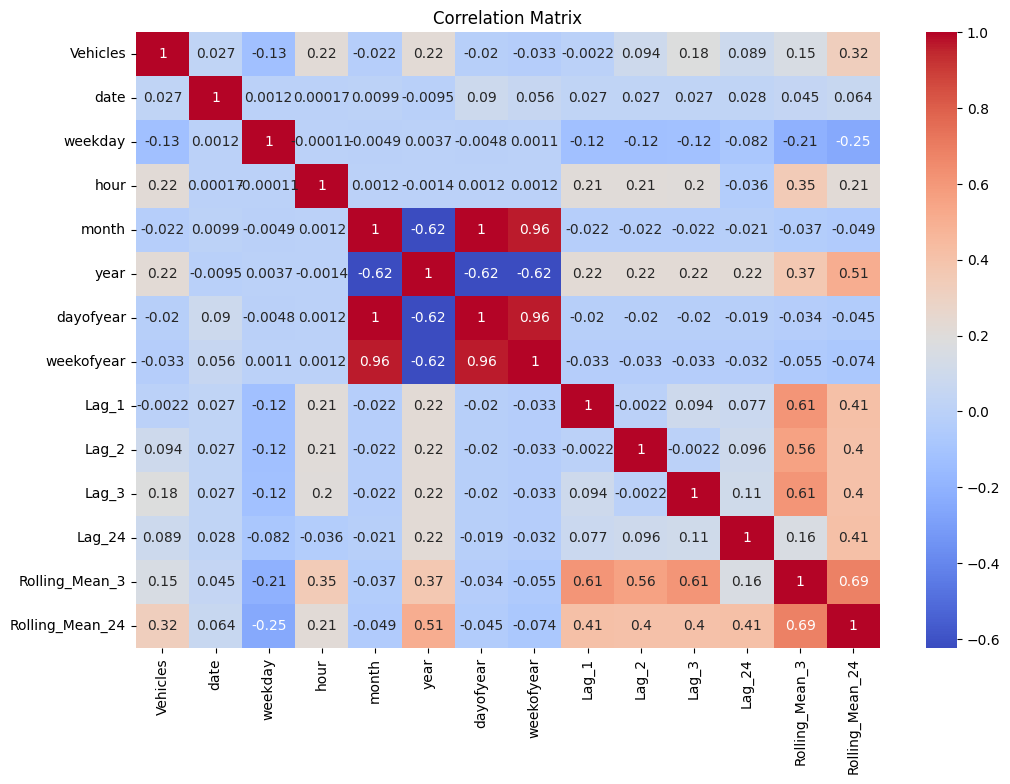

In [137]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [138]:
# SEPERATE FEATURE AND TARGET(VEHICLES)
# seperate vehicles class label and store it in target variable while keeping remaining features in df1 variable
x = df.drop(['DateTime', 'Vehicles'], axis=1)

y = df['Vehicles']
print(x.head())
y.head()

   date  weekday  hour  month  year  dayofyear  weekofyear  Lag_1  Lag_2  \
0     1        6     9     11  2015        305          44    3.0    3.0   
1     1        6     9     11  2015        305          44   12.0    3.0   
2     1        6    10     11  2015        305          44    6.0   12.0   
3     1        6    10     11  2015        305          44    8.0    6.0   
4     1        6    10     11  2015        305          44   15.0    8.0   

   Lag_3  Lag_24  Rolling_Mean_3  Rolling_Mean_24  
0   11.0    15.0        5.666667         6.500000  
1    3.0     6.0        6.000000         6.375000  
2    3.0     9.0        7.000000         6.375000  
3   12.0     6.0        8.666667         6.333333  
4    6.0    13.0        9.666667         6.708333  


,Vehicles
0,12
1,6
2,8
3,15
4,12


features are:
date
weekday
hour
month
year
dayofyear
weekofyear
Lag_1
Lag_2
Lag_3
Lag_24
Rolling_Mean_3
Rolling_Mean_24

results shows data where various time based feature like day of the month,weekday,hour,month,year,day of the year and week of the year are extracted from the Date Time column.

In [139]:
# TRAIN TEST SPLIT
split = int(len(df) * 0.8)

x_train = x.iloc[:split]
x_test = x.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [140]:
# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)


# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)


# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

In [82]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score': [
        r2_lr,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,19.895710,25.426583,0.133760
1,Random Forest,18.835012,24.450652,0.198980
2,Gradient Boosting,18.192314,24.616311,0.188089


"Among the three models, Random Forest performed best overall because it achieved the lowest RMSE of 24.4507 and the highest R² score of 0.1980. Gradient Boosting achieved a slightly lower MAE, but Random Forest provided the better overall performance based on RMSE and R².

In [141]:
# Final Best Model - Random Forest

best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

best_model.fit(x_train, y_train)

print("Final Random Forest model trained successfully!")

Final Random Forest model trained successfully!


In [84]:
# Predictions using the best model

y_pred_final = best_model.predict(x_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [142]:
comparison = pd.DataFrame({
    'Actual Vehicles': y_test.values,
    'Predicted Vehicles': y_pred_final
})

comparison.head(10)

,Actual Vehicles,Predicted Vehicles
0,35,17.85
1,88,27.54
2,98,51.00
3,36,64.71
4,5,63.86
5,21,49.39
6,8,21.31
7,96,43.13
8,21,44.92
9,32,63.21


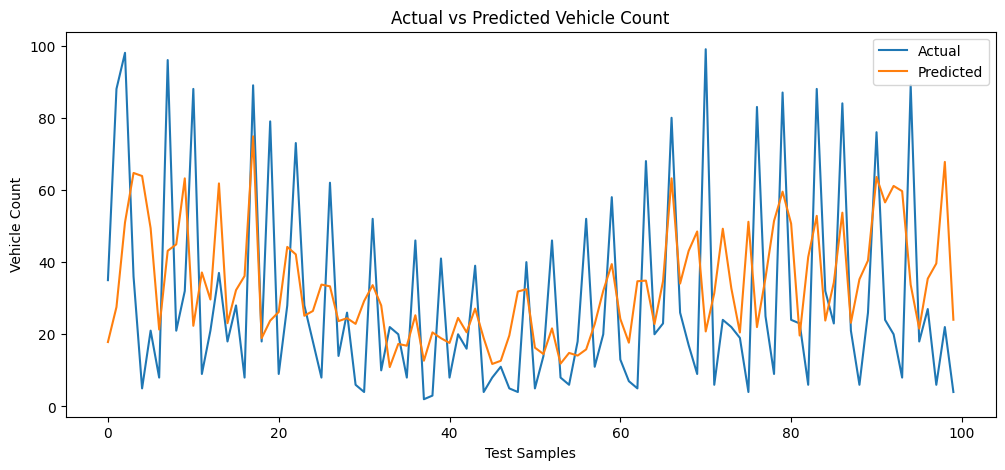

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    y_pred_final[:100],
    label='Predicted'
)

plt.xlabel('Test Samples')
plt.ylabel('Vehicle Count')
plt.title('Actual vs Predicted Vehicle Count')
plt.legend()
plt.show()

This graph compares the actual vehicle counts with the values predicted by the Random Forest model. The closer the predicted values are to the actual values, the better the prediction performance.

In [145]:
print("Model features:")
print(x_train.columns.tolist())

Model features:
['date', 'weekday', 'hour', 'month', 'year', 'dayofyear', 'weekofyear', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_24', 'Rolling_Mean_3', 'Rolling_Mean_24']


In [148]:
# ==========================================
# VEHICLE COUNT PREDICTION
# ==========================================

# Enter the date and time we want to predict
input_datetime = pd.to_datetime("2017-06-30 18:00:00")

# Get previous vehicle counts
last_vehicles = df['Vehicles'].values

# Create all 13 features
input_data = pd.DataFrame({

    'date': [input_datetime.day],
    'weekday': [input_datetime.weekday()],
    'hour': [input_datetime.hour],
    'month': [input_datetime.month],
    'year': [input_datetime.year],
    'dayofyear': [input_datetime.dayofyear],
    'weekofyear': [input_datetime.isocalendar().week],

    'Lag_1': [last_vehicles[-1]],
    'Lag_2': [last_vehicles[-2]],
    'Lag_3': [last_vehicles[-3]],
    'Lag_24': [last_vehicles[-24]],

    'Rolling_Mean_3': [last_vehicles[-3:].mean()],
    'Rolling_Mean_24': [last_vehicles[-24:].mean()]
})

# Put columns in the exact training order
input_data = input_data[x_train.columns]

# Prediction
prediction = best_model.predict(input_data)

print("=" * 45)
print("VEHICLE COUNT PREDICTION")
print("=" * 45)
print("Prediction Date & Time:", input_datetime)
print("Predicted Vehicle Count:", round(prediction[0]))

VEHICLE COUNT PREDICTION
Prediction Date & Time: 2017-06-30 18:00:00
Predicted Vehicle Count: 65
